In [2]:
import pandas as pd
df = pd.read_csv("../data/PS_20174392719_1491204439457_log.csv")
df.shape, df.dtypes
df["isFraud"].mean()
df.groupby("type")["isFraud"].agg(["count", "sum", "mean"])

,count,sum,mean
type,,,
CASH_IN,1399284,0,0.000000
CASH_OUT,2237500,4116,0.001840
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000
TRANSFER,532909,4097,0.007688


In [6]:
# 1. Overall picture
print(df.shape)
print(df["isFraud"].mean())
df.dtypes

(6362620, 11)
0.001290820448180152


gistep              int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [3]:
# 2. Do fraudsters drain the origin account?
fraud = df[df["isFraud"] == 1]
legit = df[(df["isFraud"] == 0) & df["type"].isin(["TRANSFER", "CASH_OUT"])]
print("fraud drained:", (fraud["oldbalanceOrg"] == fraud["amount"]).mean())
print("legit drained:", (legit["oldbalanceOrg"] == legit["amount"]).mean())

fraud drained: 0.9782052843053696
legit drained: 0.0


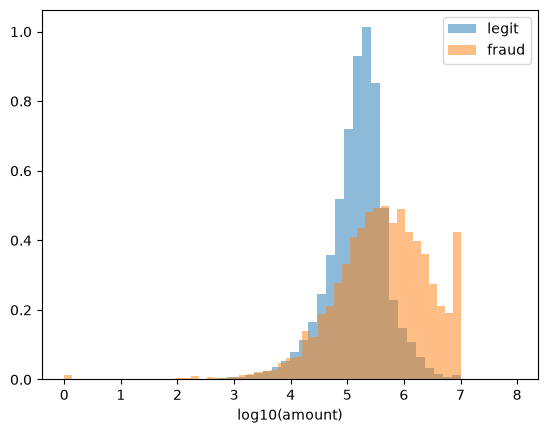

In [4]:
# 3. Amounts, fraud vs legit (log scale)
import numpy as np
import matplotlib.pyplot as plt
plt.hist(np.log10(legit["amount"] + 1), bins=50, alpha=0.5, label="legit", density=True)
plt.hist(np.log10(fraud["amount"] + 1), bins=50, alpha=0.5, label="fraud", density=True)
plt.xlabel("log10(amount)"); plt.legend(); plt.show()

In [5]:
# 4. The built-in rule flag
print(df["isFlaggedFraud"].sum())
pd.crosstab(df["isFraud"], df["isFlaggedFraud"])

16


isFlaggedFraud,0,1
isFraud,,
0,6354407,0
1,8197,16
